<a href="https://colab.research.google.com/github/v71017/MY_ML/blob/master/Cnn_tutorial_Lecture_3_day_2_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Deep Learning Hands-On: CNN from Scratch


### What we will cover
1. How images are stored as numbers (B&W → Grayscale → Colour)
2. What CNN filters do
3. Building and training a CNN on image classification
4. Why CNN struggles with text
5. Word embeddings and RNNs for text classification

### How to use this notebook
- **Pre-filled cells** — read, run, observe the output
- **✏️ DIY cells** — you write the code (hints are provided!)
- Run cells **in order**, top to bottom

---


## 0. Setup

Run this cell first. It imports everything we need for the whole notebook.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset

print("✅ All imports successful!")
print(f"   PyTorch version : {torch.__version__}")
print(f"   GPU available   : {torch.cuda.is_available()}")


✅ All imports successful!
   PyTorch version : 2.6.0+cu124
   GPU available   : True


---
## Part 1 — Images and Convolutional Neural Networks

---

### 1.1 Black & White Images

A **black & white image** is just a 2D grid of 0s and 1s.  
`0` = black pixel, `1` = white pixel. That's all.

The grid below spells out a letter "F".  
Run the cell — it will print the numbers and then display the image.


The image as a matrix of numbers:
[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 1. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 1. 1. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]


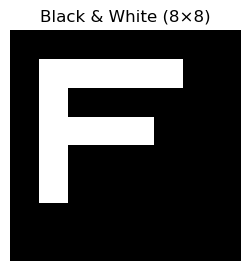

In [ ]:
bw = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 1, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
], dtype=np.float32)

print("The image as a matrix of numbers:")
print(bw)

plt.figure(figsize=(3, 3))
plt.imshow(bw, cmap='gray', vmin=0, vmax=1)
plt.title("Black & White (8×8)")
plt.axis('off')
plt.show()


---
#### ✏️ DIY 1 — Draw your own letter or shape

Edit the array below to draw something — your initials, a smiley, a cross, anything.  
Remember: `1` = white, `0` = black.


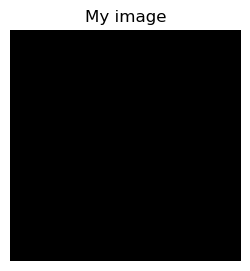

In [ ]:
# ✏️ YOUR TURN
# Edit the 0s and 1s below to draw your own 8×8 image

my_image = np.array([
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
    [0, 0, 0, 0, 0, 0, 0, 0],
], dtype=np.float32)

plt.figure(figsize=(3, 3))
plt.imshow(my_image, cmap='gray', vmin=0, vmax=1)
plt.title("My image")
plt.axis('off')
plt.show()


---
### 1.2 Grayscale Images

Grayscale adds **shades** between black and white.  
Each pixel is now an integer from **0 (black) to 255 (white)**.

This is how the MNIST handwritten digit dataset stores its images — 28×28 grayscale.

The cell below creates a random grayscale image and annotates the pixel values.


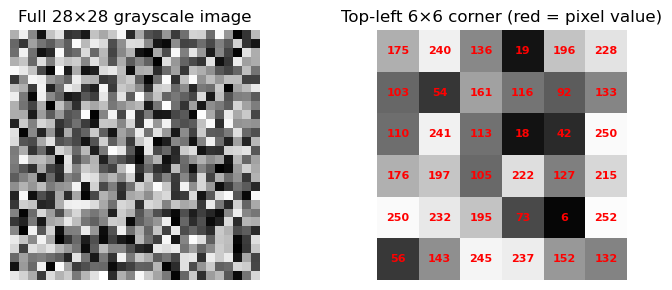

Image shape: (28, 28)  |  min: 0  max: 255


In [ ]:
np.random.seed(7)
gray = np.random.randint(0, 256, size=(28, 28), dtype=np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

# Left: full image
axes[0].imshow(gray, cmap='gray')
axes[0].set_title("Full 28×28 grayscale image")
axes[0].axis('off')

# Right: zoom into the top-left 6×6 corner, show values
corner = gray[:6, :6]
axes[1].imshow(corner, cmap='gray', vmin=0, vmax=255)
for r in range(6):
    for c in range(6):
        axes[1].text(c, r, str(corner[r, c]), ha='center', va='center',
                     fontsize=8, color='red', fontweight='bold')
axes[1].set_title("Top-left 6×6 corner (red = pixel value)")
axes[1].axis('off')

plt.tight_layout()
plt.show()
print(f"Image shape: {gray.shape}  |  min: {gray.min()}  max: {gray.max()}")


---
#### ✏️ DIY 2 — Solid colour images

What does a completely black image look like? What about a mid-grey one?  
Fill in the blanks below.


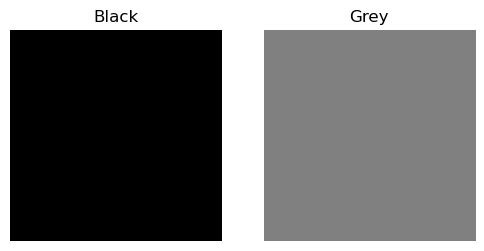

In [ ]:
# ✏️ YOUR TURN
# Hint: np.zeros((28, 28)) gives all zeros (black)
#       np.ones((28, 28))  gives all ones
#       multiply by a number to get a specific shade, e.g. np.ones(...) * 128

black_image = np.zeros((28, 28))

grey_image  = np.ones((28, 28)) * 128

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(black_image, cmap='gray', vmin=0, vmax=255)
axes[0].set_title("Black")
axes[0].axis('off')
axes[1].imshow(grey_image, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Grey")
axes[1].axis('off')
plt.show()


---
### 1.3 Colour (RGB) Images

A colour image has **3 channels stacked together**: Red, Green, Blue.  
Each channel is a grayscale grid. The full image has shape **(Height, Width, 3)**.

PyTorch uses a different convention: **(3, Height, Width)** — channels come first.


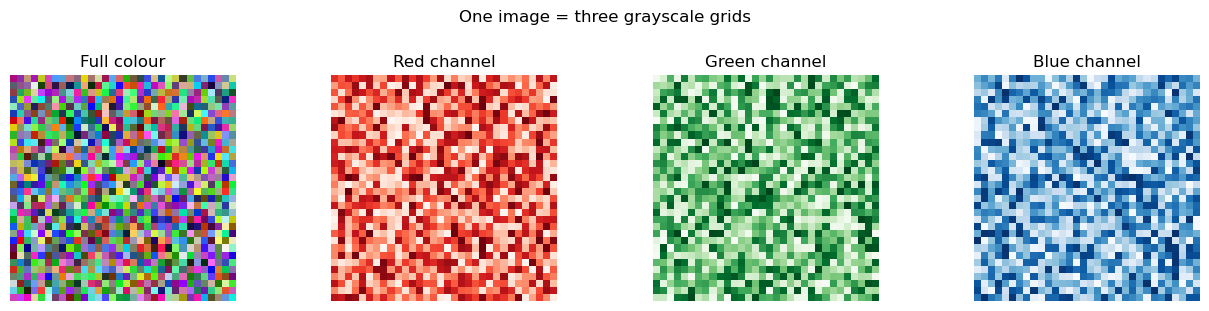

NumPy shape (H, W, C): (32, 32, 3)


In [ ]:
np.random.seed(0)
rgb = np.random.randint(0, 256, size=(32, 32, 3), dtype=np.uint8)

fig, axes = plt.subplots(1, 4, figsize=(13, 3))
axes[0].imshow(rgb);                              axes[0].set_title("Full colour")
axes[1].imshow(rgb[:,:,0], cmap='Reds');          axes[1].set_title("Red channel")
axes[2].imshow(rgb[:,:,1], cmap='Greens');        axes[2].set_title("Green channel")
axes[3].imshow(rgb[:,:,2], cmap='Blues');         axes[3].set_title("Blue channel")
for ax in axes: ax.axis('off')
plt.suptitle("One image = three grayscale grids", y=1.02)
plt.tight_layout()
plt.show()

print(f"NumPy shape (H, W, C): {rgb.shape}")


In [ ]:
# Converting to a PyTorch tensor
# Step 1: permute — move channels from last to first
# Step 2: normalise — divide by 255 so values are 0.0 to 1.0

tensor = torch.from_numpy(rgb).permute(2, 0, 1).float() / 255.0

print(f"NumPy  shape  (H, W, C) : {rgb.shape}")
print(f"Tensor shape  (C, H, W) : {tuple(tensor.shape)}")
print(f"Value range             : {tensor.min():.2f}  to  {tensor.max():.2f}")


NumPy  shape  (H, W, C) : (32, 32, 3)
Tensor shape  (C, H, W) : (3, 32, 32)
Value range             : 0.00  to  1.00


---
#### ✏️ DIY 3 — Make a solid red image

Create a 32×32 RGB image where every pixel is pure red (R=255, G=0, B=0)  
and display it with `imshow`.


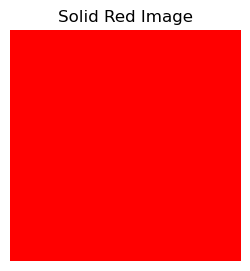

In [ ]:
# ✏️ YOUR TURN
# Hint: start with np.zeros((32, 32, 3), dtype=np.uint8)
#       then set the Red channel: img[:, :, 0] = 255

red_image = np.zeros((32, 32, 3), dtype=np.uint8)
red_image[:, :, 0] = 255

plt.figure(figsize=(3, 3))
plt.imshow(red_image)
plt.title("Solid Red Image")
plt.axis('off')
plt.show()


---
### 1.4 What Do CNN Filters Do?

A **filter** (or kernel) is a small matrix — typically 3×3.  
It slides across the image, multiplies element-wise with each patch, and sums the result.  
This gives one number per patch — the **filter's response** at that location.

Different filters detect different patterns. Let's see three.


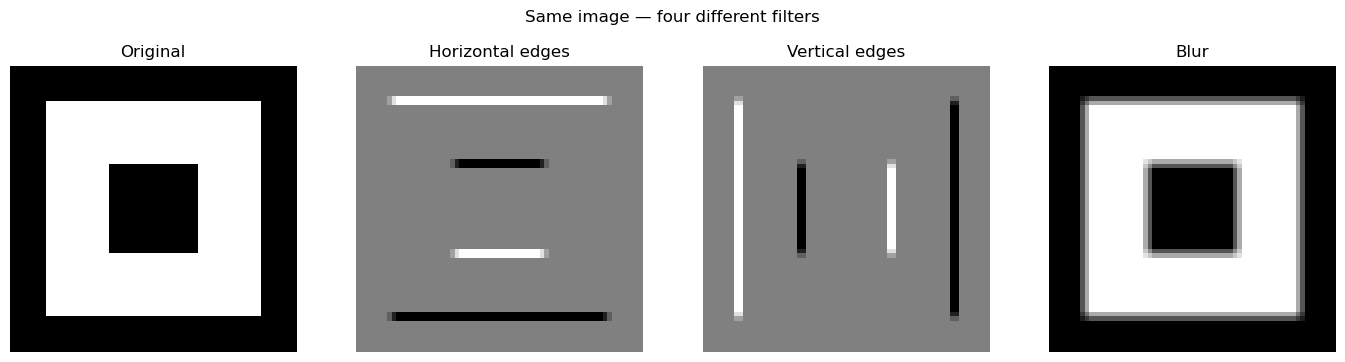

In [ ]:
# Test image — a bright square with a hollow centre
img = np.zeros((64, 64), dtype=np.float32)
img[8:56, 8:56] = 1.0     # outer square
img[22:42, 22:42] = 0.0   # hollow

def apply_filter(image, kernel):
    t = torch.from_numpy(image).unsqueeze(0).unsqueeze(0)   # (1, 1, H, W)
    k = torch.from_numpy(kernel.astype(np.float32)).unsqueeze(0).unsqueeze(0)
    with torch.no_grad():
        return F.conv2d(t, k, padding=1).squeeze().numpy()

f_horiz  = np.array([[-1.,-2.,-1.],[ 0., 0., 0.],[ 1., 2., 1.]])   # horizontal edges
f_vert   = np.array([[-1., 0., 1.],[-2., 0., 2.],[-1., 0., 1.]])   # vertical edges
f_blur   = np.ones((3, 3)) / 9.0                                     # average blur

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
for ax, (title, data) in zip(axes, [
    ("Original",          img),
    ("Horizontal edges",  apply_filter(img, f_horiz)),
    ("Vertical edges",    apply_filter(img, f_vert)),
    ("Blur",              apply_filter(img, f_blur)),
]):
    ax.imshow(data, cmap='gray')
    ax.set_title(title)
    ax.axis('off')

plt.suptitle("Same image — four different filters", y=1.02)
plt.tight_layout()
plt.show()


---
#### ✏️ DIY 4 — Sharpening filter

A sharpening filter emphasises edges and makes the image look crisper.  
Fill in the kernel values and apply it to the same test image.

```
Sharpening kernel:
 [ 0, -1,  0]
 [-1,  5, -1]
 [ 0, -1,  0]
```


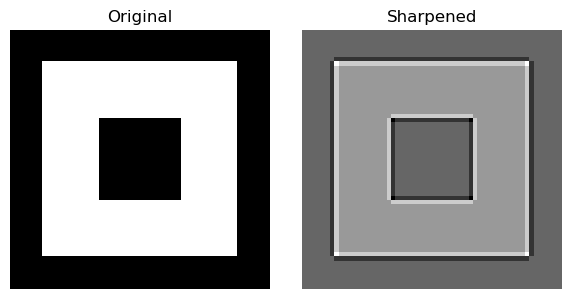

In [ ]:
# ✏️ YOUR TURN
# Define the sharpening filter using the values above

f_sharp = np.array([
    [ 0., -1.,  0.],
    [-1.,  5., -1.],
    [ 0., -1.,  0.],
])

result = apply_filter(img, f_sharp)

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(img, cmap='gray');    axes[0].set_title("Original"); axes[0].axis('off')
axes[1].imshow(result, cmap='gray'); axes[1].set_title("Sharpened"); axes[1].axis('off')
plt.tight_layout()
plt.show()


---
### 1.5 From Image to Vector

A CNN stacks Conv + Pool layers to gradually compress the image.  
At the end, a **Flatten** turns the 3D feature maps into a 1D vector — the image's "summary".  
That vector goes into a fully-connected layer to make a class prediction.

```
(3, 32, 32) → Conv → Pool → Conv → Pool → Flatten → (vector) → FC → class
```

Run the cell to trace the shapes step by step.


In [ ]:
x = torch.randn(1, 3, 32, 32)
print(f"Input              : {tuple(x.shape)}")

c1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
x  = F.relu(c1(x))
print(f"After Conv1 + ReLU : {tuple(x.shape)}   ← 16 filters, spatial size unchanged (padding=1)")

x  = F.max_pool2d(x, 2)
print(f"After MaxPool      : {tuple(x.shape)}   ← halved by pooling")

c2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
x  = F.relu(c2(x))
print(f"After Conv2 + ReLU : {tuple(x.shape)}   ← 32 filters")

x  = F.max_pool2d(x, 2)
print(f"After MaxPool      : {tuple(x.shape)}   ← halved again")

x  = x.view(x.size(0), -1)
print(f"After Flatten      : {tuple(x.shape)}   ← this is the feature vector")
print(f"32×32 colour image  →  {x.shape[1]}-number summary")


Input              : (1, 3, 32, 32)
After Conv1 + ReLU : (1, 16, 32, 32)   ← 16 filters, spatial size unchanged (padding=1)
After MaxPool      : (1, 16, 16, 16)   ← halved by pooling
After Conv2 + ReLU : (1, 32, 16, 16)   ← 32 filters
After MaxPool      : (1, 32, 8, 8)   ← halved again
After Flatten      : (1, 2048)   ← this is the feature vector
32×32 colour image  →  2048-number summary


---
#### ✏️ DIY 5 — What if the input is bigger?

Change the input to a **64×64** image and re-run the shape trace.  
What is the size of the final feature vector?


In [ ]:
# ✏️ YOUR TURN
# Change the input size from (1, 3, 32, 32) to (1, 3, 64, 64) and run

x = torch.randn(1, 3, 64, 64)
print(f"Input              : {tuple(x.shape)}")

c1 = nn.Conv2d(3, 16, kernel_size=3, padding=1)
x  = F.relu(c1(x))
print(f"After Conv1 + ReLU : {tuple(x.shape)}")

x  = F.max_pool2d(x, 2)
print(f"After MaxPool      : {tuple(x.shape)}")

c2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
x  = F.relu(c2(x))
print(f"After Conv2 + ReLU : {tuple(x.shape)}")

x  = F.max_pool2d(x, 2)
print(f"After MaxPool      : {tuple(x.shape)}")

x  = x.view(x.size(0), -1)
print(f"After Flatten      : {tuple(x.shape)}")
print(f"Final feature vector size: {x.shape[1]}")


Input              : (1, 3, 64, 64)
After Conv1 + ReLU : (1, 16, 64, 64)
After MaxPool      : (1, 16, 32, 32)
After Conv2 + ReLU : (1, 32, 32, 32)
After MaxPool      : (1, 32, 16, 16)
After Flatten      : (1, 8192)
Final feature vector size: 8192


---
### 1.6 Building a CNN for CIFAR-10

**CIFAR-10** — 60,000 colour images (32×32), 10 classes:  
✈️ airplane · 🚗 car · 🐦 bird · 🐱 cat · 🦌 deer · 🐶 dog · 🐸 frog · 🐴 horse · 🚢 ship · 🚚 truck

Here is our model. Read through it!


In [ ]:
# Load CIFAR-10 data
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465],
                         std =[0.2470, 0.2435, 0.2616])
])

# Download directly into the Colab session; Google Drive is not needed.
# Do not fall back to FakeData here: FakeData is random noise, not CIFAR-10.
train_full = datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_full  = datasets.CIFAR10('./data', train=False, download=True, transform=transform)

# Use one genuine image from each class for a very fast classroom demonstration.
train_indices = [train_full.targets.index(class_id) for class_id in range(10)]
test_indices  = [test_full.targets.index(class_id) for class_id in range(10)]
train_data = Subset(train_full, train_indices)
test_data  = Subset(test_full, test_indices)

train_loader = DataLoader(train_data, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=256, shuffle=False)

print(f"Train: {len(train_data):,}  |  Test: {len(test_data):,}")
print("Dataset: genuine CIFAR-10 (one image per class)")


Train: 10  |  Test: 10
Dataset: genuine CIFAR-10 (one image per class)


Training tensor: shape=(10, 3, 32, 32), range=[-1.989, 2.110]
Display image:   shape=(32, 32, 3), range=[0.031, 0.988]


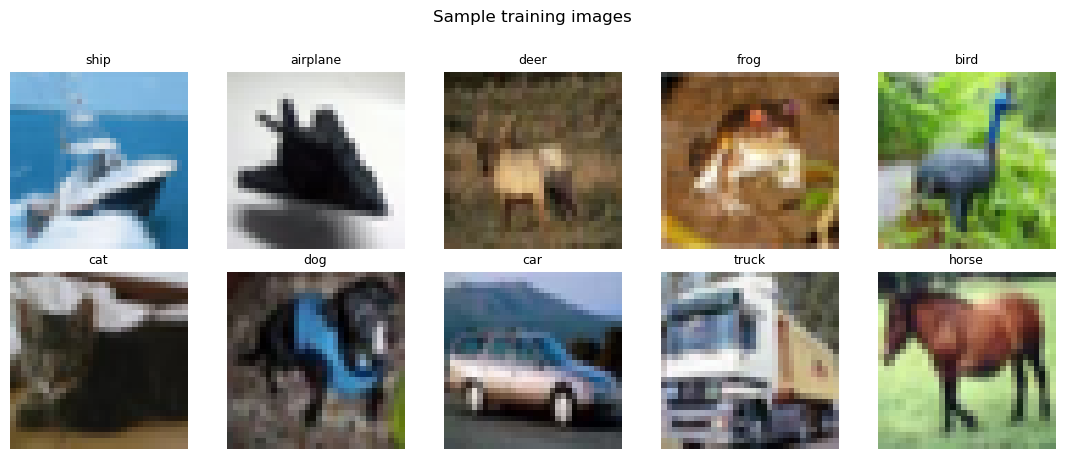

In [ ]:
# Peek at a batch of images before training
class_names = ['airplane','car','bird','cat','deer','dog','frog','horse','ship','truck']
imgs, lbls = next(iter(train_loader))

CIFAR_MEAN = torch.tensor([0.4914, 0.4822, 0.4465]).view(3, 1, 1)
CIFAR_STD  = torch.tensor([0.2470, 0.2435, 0.2616]).view(3, 1, 1)

def imshow_denormalized(image, ax):
    # The CNN trains on normalized [C, H, W] tensors.
    image = image.cpu() * CIFAR_STD + CIFAR_MEAN  # undo Normalize
    image = image.permute(1, 2, 0)                # [C,H,W] -> [H,W,C]
    ax.imshow(image.clamp(0, 1).numpy())

display_img = imgs[0].cpu() * CIFAR_STD + CIFAR_MEAN
print(f"Training tensor: shape={tuple(imgs.shape)}, range=[{imgs.min():.3f}, {imgs.max():.3f}]")
print(f"Display image:   shape={tuple(display_img.permute(1, 2, 0).shape)}, "
      f"range=[{display_img.min():.3f}, {display_img.max():.3f}]")

fig, axes = plt.subplots(2, 5, figsize=(11, 4.5))
for i, ax in enumerate(axes.flat):
    imshow_denormalized(imgs[i], ax)
    ax.set_title(class_names[lbls[i].item()], fontsize=9)
    ax.axis('off')
plt.suptitle("Sample training images", y=1.01)
plt.tight_layout()
plt.show()


In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super().__init__()
        # --- Feature extractor ---
        self.conv1 = nn.Conv2d(3,  32, kernel_size=3, padding=1)  # 32×32 → 32×32    -> (1, 3, x, y) -> (1, 32, x, y)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # 16×16 → 16×16   -> (1, 32, x, y) -> (1, 64, x, y)
        self.pool  = nn.MaxPool2d(2, 2)                            # halves H and W

        # --- Classifier ---
        # After 2 pools: 32→16→8, with 64 channels → 64*8*8 = 4096
        self.fc1  = nn.Linear(64 * 8 * 8, 256)
        self.fc2  = nn.Linear(256, 10)         # 10 output classes
        self.drop = nn.Dropout(0.4)            # randomly zero 40% during training

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))   # Conv → ReLU → Pool
        x = self.pool(F.relu(self.conv2(x)))   # Conv → ReLU → Pool
        x = x.view(x.size(0), -1)              # Flatten
        x = self.drop(F.relu(self.fc1(x)))
        x = self.fc2(x)                        # raw scores (no softmax — loss handles it)
        return x

model = SimpleCNN()
total_params = sum(p.numel() for p in model.parameters())
print(f"Model ready. Total parameters: {total_params:,}")


Model ready. Total parameters: 1,070,794


1. Define a model
2. Forward pass (with an image)
3. Calculate the loss
4. Calculate the gradients
5. Update those gradients for the parameters.

In [ ]:
# Training loop
device    = 'cuda' if torch.cuda.is_available() else 'cpu'
model     = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) #write the code here
criterion = nn.CrossEntropyLoss() #write the code here

train_acc_hist, test_acc_hist = [], []
NUM_EPOCHS = 5

for epoch in range(1, NUM_EPOCHS + 1):
    # --- train ---
    model.train()      #write the code here
    correct = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()   #write the code here
        out  = model(imgs)    #write the code here
        loss = criterion(out, lbls)  #write the code here
        loss.backward()       #write the code here
        optimizer.step()         #write the code here
        correct += (out.argmax(1) == lbls).sum().item()
    train_acc_hist.append(correct / len(train_data))

    # --- evaluate ---
    model.eval()
    correct = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            correct += (model(imgs).argmax(1) == lbls).sum().item()
    test_acc_hist.append(correct / len(test_data))

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS}  |  "
          f"train: {train_acc_hist[-1]:.1%}  |  test: {test_acc_hist[-1]:.1%}")


Epoch  1/5  |  train: 0.0%  |  test: 10.0%
Epoch  2/5  |  train: 30.0%  |  test: 10.0%
Epoch  3/5  |  train: 50.0%  |  test: 20.0%
Epoch  4/5  |  train: 70.0%  |  test: 20.0%
Epoch  5/5  |  train: 90.0%  |  test: 20.0%


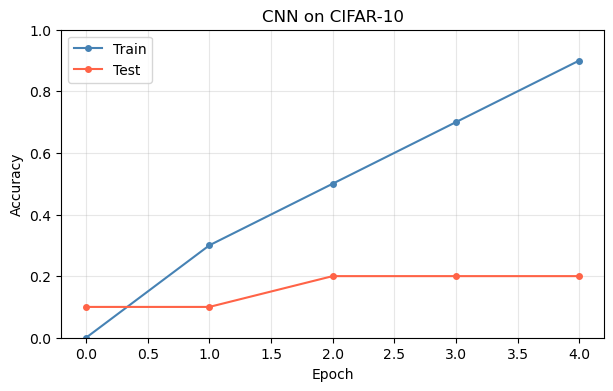

Final test accuracy: 20.0%


In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(train_acc_hist, label='Train', color='steelblue', marker='o', markersize=4)
plt.plot(test_acc_hist,  label='Test',  color='tomato',    marker='o', markersize=4)
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("CNN on CIFAR-10"); plt.ylim(0, 1)
plt.legend(); plt.grid(alpha=0.3)
plt.show()
print(f"Final test accuracy: {test_acc_hist[-1]:.1%}")


In [ ]:
# Training loop
device    = 'cuda' if torch.cuda.is_available() else 'cpu'
model     = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3) #write the code here
criterion = nn.CrossEntropyLoss() #write the code here

train_acc_hist, test_acc_hist = [], []
NUM_EPOCHS = 10

for epoch in range(1, NUM_EPOCHS + 1):
    # --- train ---
    model.train()      #write the code here
    correct = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        optimizer.zero_grad()   #write the code here
        out  = model(imgs)    #write the code here
        loss = criterion(out, lbls)  #write the code here
        loss.backward()       #write the code here
        optimizer.step()         #write the code here
        correct += (out.argmax(1) == lbls).sum().item()
    train_acc_hist.append(correct / len(train_data))

    # --- evaluate ---
    model.eval()
    correct = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            correct += (model(imgs).argmax(1) == lbls).sum().item()
    test_acc_hist.append(correct / len(test_data))

    print(f"Epoch {epoch:2d}/{NUM_EPOCHS}  |  "
          f"train: {train_acc_hist[-1]:.1%}  |  test: {test_acc_hist[-1]:.1%}")


Epoch  1/10  |  train: 0.0%  |  test: 10.0%
Epoch  2/10  |  train: 20.0%  |  test: 0.0%
Epoch  3/10  |  train: 70.0%  |  test: 0.0%
Epoch  4/10  |  train: 80.0%  |  test: 10.0%
Epoch  5/10  |  train: 90.0%  |  test: 10.0%
Epoch  6/10  |  train: 100.0%  |  test: 10.0%
Epoch  7/10  |  train: 100.0%  |  test: 20.0%
Epoch  8/10  |  train: 100.0%  |  test: 20.0%
Epoch  9/10  |  train: 100.0%  |  test: 20.0%
Epoch 10/10  |  train: 100.0%  |  test: 20.0%


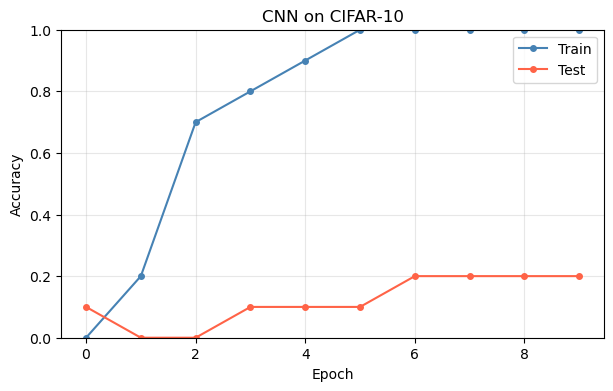

Final test accuracy: 20.0%


In [ ]:
plt.figure(figsize=(7, 4))
plt.plot(train_acc_hist, label='Train', color='steelblue', marker='o', markersize=4)
plt.plot(test_acc_hist,  label='Test',  color='tomato',    marker='o', markersize=4)
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("CNN on CIFAR-10"); plt.ylim(0, 1)
plt.legend(); plt.grid(alpha=0.3)
plt.show()
print(f"Final test accuracy: {test_acc_hist[-1]:.1%}")

---
#### ✏️ DIY 6 — More filters in the first conv layer

Our `conv1` uses **32 filters**. Try increasing it to **64**.  
You will need to update `conv2`'s `in_channels` to match, and recalculate `fc1`'s input size.

Fill in the model below and train it. Does more filters help?


In [ ]:
# ✏️ YOUR TURN — increase the number of filters
# conv1: 3 → 64 filters (was 32)
# conv2: must take 64 as input (was 32)
# fc1  : input size changes — what is 64 * 8 * 8 ?  (stays the same actually — why?)

class WiderCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 8 * 8, 256)
        self.fc2   = nn.Linear(256, 10)
        self.drop  = nn.Dropout(0.4)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = self.drop(F.relu(self.fc1(x)))
        return self.fc2(x)

# Quick test — does the model run without errors?
test_model = WiderCNN()
dummy = torch.randn(2, 3, 32, 32)
print("Output shape:", test_model(dummy).shape)   # should be (2, 10)
print(f"Parameters: {sum(p.numel() for p in test_model.parameters()):,}")


Output shape: torch.Size([2, 10])
Parameters: 1,090,122


In [ ]:
# Train the wider CNN using the same setup as above
wider_model = WiderCNN().to(device)
wider_optimizer = torch.optim.Adam(wider_model.parameters(), lr=1e-3)
wider_criterion = nn.CrossEntropyLoss()
wider_train_acc_hist, wider_test_acc_hist = [], []

for epoch in range(1, 6):
    wider_model.train()
    correct = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        wider_optimizer.zero_grad()
        out = wider_model(imgs)
        loss = wider_criterion(out, lbls)
        loss.backward()
        wider_optimizer.step()
        correct += (out.argmax(1) == lbls).sum().item()
    wider_train_acc_hist.append(correct / len(train_data))

    wider_model.eval()
    correct = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            correct += (wider_model(imgs).argmax(1) == lbls).sum().item()
    wider_test_acc_hist.append(correct / len(test_data))
    print(f"WiderCNN epoch {epoch}/5 | train: {wider_train_acc_hist[-1]:.1%} | test: {wider_test_acc_hist[-1]:.1%}")


WiderCNN epoch 1/5 | train: 10.0% | test: 20.0%
WiderCNN epoch 2/5 | train: 30.0% | test: 10.0%
WiderCNN epoch 3/5 | train: 40.0% | test: 10.0%
WiderCNN epoch 4/5 | train: 60.0% | test: 20.0%
WiderCNN epoch 5/5 | train: 80.0% | test: 20.0%


---
#### ✏️ DIY 7 — Remove Dropout and observe overfitting

**Dropout** randomly zeroes out neurons during training — it acts as a regulariser  
and helps prevent **overfitting** (when the model memorises training data but fails on new data).

Copy the training loop from above, remove `self.drop` from the model, retrain, and compare the curves.  
You should see train accuracy climb much higher than test accuracy.


In [ ]:
# ✏️ YOUR TURN — train a model WITHOUT Dropout and compare curves

class NoDropCNN(nn.Module):   # fix the class name (remove the space)
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(64 * 8 * 8, 256)
        self.fc2   = nn.Linear(256, 10)
        # Dropout removed intentionally

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))   # no dropout here
         # Code for dropout goes here
        return self.fc2(x)

# write the training loop here (copy from the cell above, just swap the model)
# Then plot the curves and compare to the version WITH Dropout


NoDropCNN epoch 1/5 | train: 10.0% | test: 20.0%
NoDropCNN epoch 2/5 | train: 60.0% | test: 10.0%


NoDropCNN epoch 3/5 | train: 100.0% | test: 20.0%
NoDropCNN epoch 4/5 | train: 100.0% | test: 10.0%
NoDropCNN epoch 5/5 | train: 100.0% | test: 10.0%


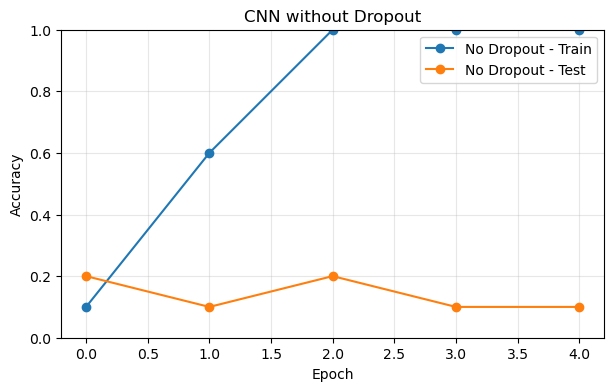

In [ ]:
# Train the no-dropout CNN and compare
no_drop_model = NoDropCNN().to(device)
no_drop_optimizer = torch.optim.Adam(no_drop_model.parameters(), lr=1e-3)
no_drop_criterion = nn.CrossEntropyLoss()
no_drop_train_acc_hist, no_drop_test_acc_hist = [], []

for epoch in range(1, 6):
    no_drop_model.train()
    correct = 0
    for imgs, lbls in train_loader:
        imgs, lbls = imgs.to(device), lbls.to(device)
        no_drop_optimizer.zero_grad()
        out = no_drop_model(imgs)
        loss = no_drop_criterion(out, lbls)
        loss.backward()
        no_drop_optimizer.step()
        correct += (out.argmax(1) == lbls).sum().item()
    no_drop_train_acc_hist.append(correct / len(train_data))

    no_drop_model.eval()
    correct = 0
    with torch.no_grad():
        for imgs, lbls in test_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            correct += (no_drop_model(imgs).argmax(1) == lbls).sum().item()
    no_drop_test_acc_hist.append(correct / len(test_data))
    print(f"NoDropCNN epoch {epoch}/5 | train: {no_drop_train_acc_hist[-1]:.1%} | test: {no_drop_test_acc_hist[-1]:.1%}")

plt.figure(figsize=(7, 4))
plt.plot(no_drop_train_acc_hist, label='No Dropout - Train', marker='o')
plt.plot(no_drop_test_acc_hist, label='No Dropout - Test', marker='o')
plt.xlabel("Epoch"); plt.ylabel("Accuracy")
plt.title("CNN without Dropout")
plt.ylim(0, 1); plt.legend(); plt.grid(alpha=0.3)
plt.show()
